# ___Segment Anything Model (SAM)___
-------------------------

In [37]:
import gc

from segment_anything import SamPredictor, SamAutomaticMaskGenerator, build_sam_vit_h
from PIL import Image # the problem is in the way OpenCV and PIL reads and parses images I guess????
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

In [47]:
def show_anns(anns, ax):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [14]:
model = SamAutomaticMaskGenerator(build_sam_vit_h(r"../bin/sam_vit_h_4b8939.pth"))

In [30]:
dog_pil = np.array(Image.open(r"../images/dog.jpg"), dtype=np.uint8)
dog_cv2 = cv2.imread(r"../images/dog.jpg")

In [35]:
(dog_pil == dog_cv2).mean()

np.float64(0.3448813982521848)

In [36]:
(dog_pil == cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB)).mean() # OpenCV reads in images in BGR colour channels by default but PIL uses RGB channel by default

np.float64(1.0)

In [38]:
masks_pil = model.generate(dog_pil)
masks_cv2 = model.generate(cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB))

In [48]:
masks_pil;

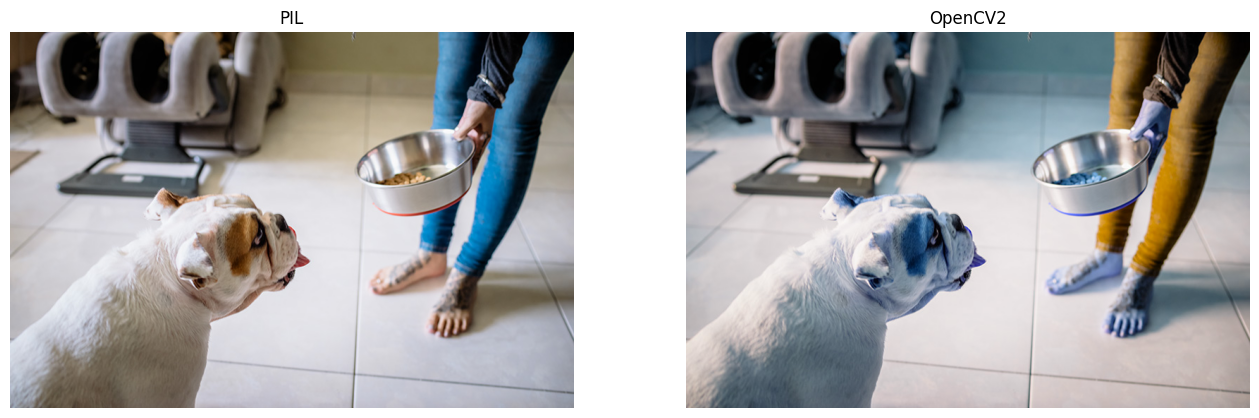

In [43]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")

plt.show()

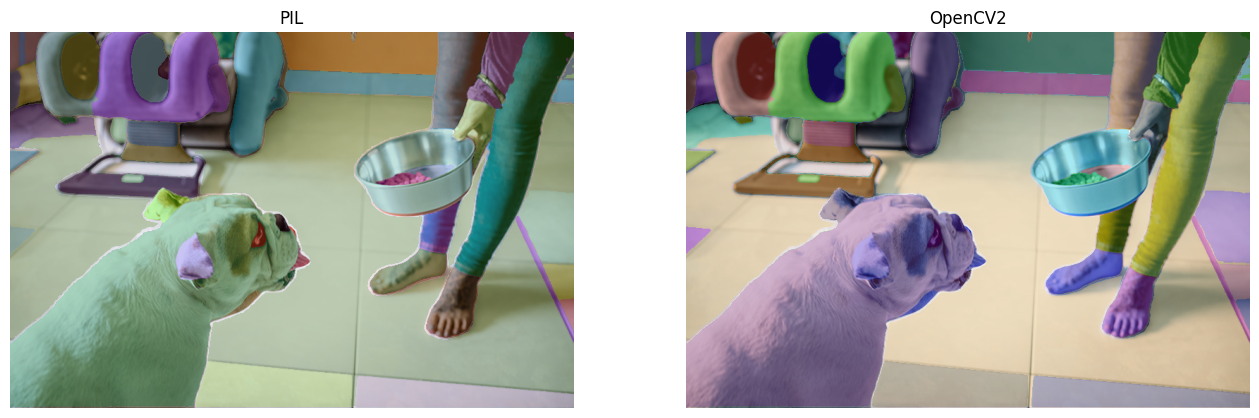

In [49]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")
show_anns(masks_pil, ax=axis_l)

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")
show_anns(masks_cv2, ax=axis_r)

plt.show()